In [12]:
## Reading the Data and Importing any libraries

import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import train_test_split


In [13]:
## Reading the data

mnist = scipy.io.loadmat('mnist-original.mat')
mnist_data = np.transpose(mnist['data'])
mnist_label = np.transpose(mnist['label'])
print(mnist_data.shape,' ',mnist_label.shape)

(70000, 784)   (70000, 1)


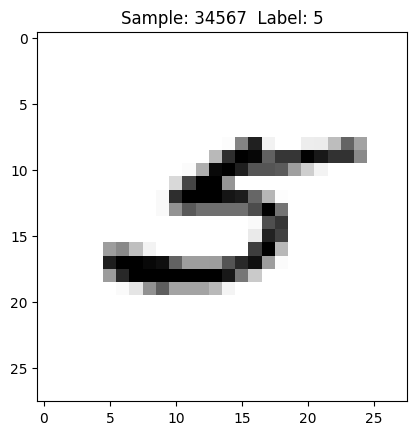

In [14]:
def display_sample(num):
    #Print the one-hot array of this sample's label
    #print(mnist_label[num])
    #Print the label converted back to a number
    label = mnist_label[num][0]
    #Reshape the 784 values to a 28x28 image
    image = mnist_data[num].reshape([28,28])
    plt.title('Sample: %d  Label: %d' % (num, label))
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()

display_sample(34567)

## Split the Data into Train and Test

In [15]:
# test_size: what proportion of original data is used for test set
train_img, test_img, train_lbl, test_lbl = train_test_split(
    mnist_data, mnist_label, test_size=(1/7.0), random_state=101)

In [16]:
print(train_img.shape)
print(train_lbl.shape)
print(test_img.shape)
print(test_lbl.shape)

(60000, 784)
(60000, 1)
(10000, 784)
(10000, 1)


In [17]:
np.unique(mnist_label, return_counts=True)

(array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 array([6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958]))

## Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(train_img, train_lbl.ravel())

y_pred=rfc.predict(test_img)

In [19]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(test_lbl, y_pred))

Accuracy: 0.9741


In [20]:
fi = rfc.feature_importances_

In [21]:
type(fi)

with np.printoptions(threshold=np.inf):
    print(fi)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.68219754e-07 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 7.23859371e-07 2.38893997e-06
 4.96964296e-06 2.47011763e-06 1.41095339e-06 1.26809422e-06
 4.95367072e-06 1.41632277e-06 4.99475351e-06 3.17409025e-06
 2.37231306e-06 1.09940871e-06 1.34436342e-06 0.00000000e+00
 3.67322010e-07 2.19101993e-06 1.03803946e-06 1.40406491e-06
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 6.98039451e-07 9.17412150e-07 8.11260271e-06
 6.73850203e-06 3.100077

In [ ]:
np.median(fi)

np.float64(0.0002928137427035233)